# prev-quality covariate 유무 A/B — 실측치 데이터

`blaine_prev` / `residue_prev` (직전 lab 실측값, sparse) 를 **known-future covariate로 넣을 때 vs 아예 뺄 때** 성능 비교. 구 folder 2026-08-12 비교의 실측치 재현.

- context_length = 2026-09-06 스윕 최적값 (**blaine 512 / residue 256**)
- full fine-tune / predlen 4 / 1000 steps / lr 1e-6 / batch 64 / stride 4
- `prev` arm = 현행 canonical (sparse prev, 두 타깃 모델 다 blaine_prev+residue_prev 사용)
- `noprev` arm = `--no-prev` (두 컬럼 완전 제거 — past covariate로도 안 들어감)
- 같은 canonical CSV, 같은 평가 지점 / naive baseline → 공정 비교

정규화 skill-score `< 1` = naive(직전값 반복) 이김. GPU 안 씀.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    pass

ROOT = Path.cwd()
while not (ROOT / 'config.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import config as cfg
from eval.metrics_utils import compute_metrics, macro_average_mae, normalized_skill_score

CTX = {'blaine': 512, 'residue': 256}
ARMS = ['noprev', 'prev']
LABEL = {'noprev': 'prev 미사용', 'prev': 'prev 사용 (sparse)'}
COLOR = {'noprev': 'tab:red', 'prev': 'tab:green'}


## 1. 결과 로딩

In [2]:
res, missing = {}, []
for t in cfg.TARGET_COLS:
    for arm in ARMS:
        p = ROOT / 'eval' / f'backtest_{t}_ctx{CTX[t]}_{arm}.csv'
        if p.exists():
            res[(t, arm)] = pd.read_csv(p, parse_dates=['timestamp'])
        else:
            missing.append(p.name)
print('missing:', missing or 'NONE', '| loaded:', len(res), '/ 4')


missing: NONE | loaded: 4 / 4


## 2. 요약표

In [3]:
rows = []
for t in cfg.TARGET_COLS:
    for arm in ARMS:
        df = res.get((t, arm))
        if df is None:
            continue
        m = compute_metrics(df, cfg.SPEC_RANGES[t])
        rows.append({'target': t, 'arm': arm, 'ctx': CTX[t], 'n': len(df),
                     'MAE': round(m['MAE'], 4), 'R2': round(m['R2'], 4),
                     'spec%': round(m['spec_accuracy'] * 100, 2),
                     'cov80%': round(m['interval_coverage'] * 100, 2),
                     'macro_MAE': round(macro_average_mae(df), 4),
                     'skill': round(normalized_skill_score(df), 4),
                     'naive_MAE': round(float(np.abs(df['actual'] - df['naive_pred']).mean()), 4)})
summary = pd.DataFrame(rows).set_index(['target', 'arm'])
summary


ctx    n      MAE      R2  spec%  cov80%  macro_MAE   skill  \
target  arm                                                                   
blaine  noprev  512  851  69.9970  0.4671  70.86   67.57    69.9635  0.8363   
        prev    512  851  69.6349  0.4737  70.15   66.16    69.5736  0.8319   
residue noprev  256  856   0.4588  0.7700  83.88   70.21     0.4585  0.8090   
        prev    256  856   0.4585  0.7701  83.06   69.74     0.4581  0.8086   

                naive_MAE  
target  arm                
blaine  noprev    83.7673  
        prev      83.7673  
residue noprev     0.5685  
        prev       0.5685

## 3. Δ (prev 사용 − 미사용)

음수 = prev 사용이 나음 (MAE/skill 기준).

In [4]:
for t in cfg.TARGET_COLS:
    a, b = res[(t, 'noprev')], res[(t, 'prev')]
    ma, mb = compute_metrics(a, cfg.SPEC_RANGES[t]), compute_metrics(b, cfg.SPEC_RANGES[t])
    sa, sb = normalized_skill_score(a), normalized_skill_score(b)
    print(f'{t:8s} (ctx {CTX[t]}):  ΔMAE={mb["MAE"]-ma["MAE"]:+.4f}  ΔR2={mb["R2"]-ma["R2"]:+.4f}  '
          f'Δskill={sb-sa:+.4f}   |  noprev skill={sa:.4f}  prev skill={sb:.4f}')


blaine   (ctx 512):  ΔMAE=-0.3621  ΔR2=+0.0065  Δskill=-0.0045   |  noprev skill=0.8363  prev skill=0.8319
residue  (ctx 256):  ΔMAE=-0.0003  ΔR2=+0.0002  Δskill=-0.0005   |  noprev skill=0.8090  prev skill=0.8086


## 4. 타깃별 비교 그래프

빨강 = prev 미사용, 초록 = prev 사용. MAE 패널 회색 점선 = naive baseline.

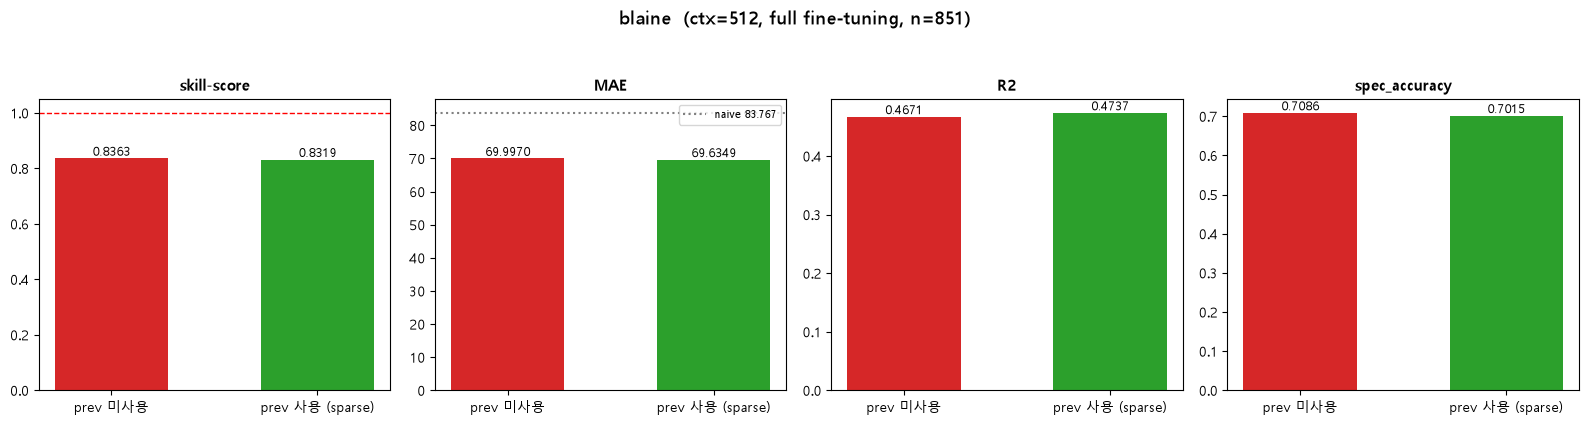

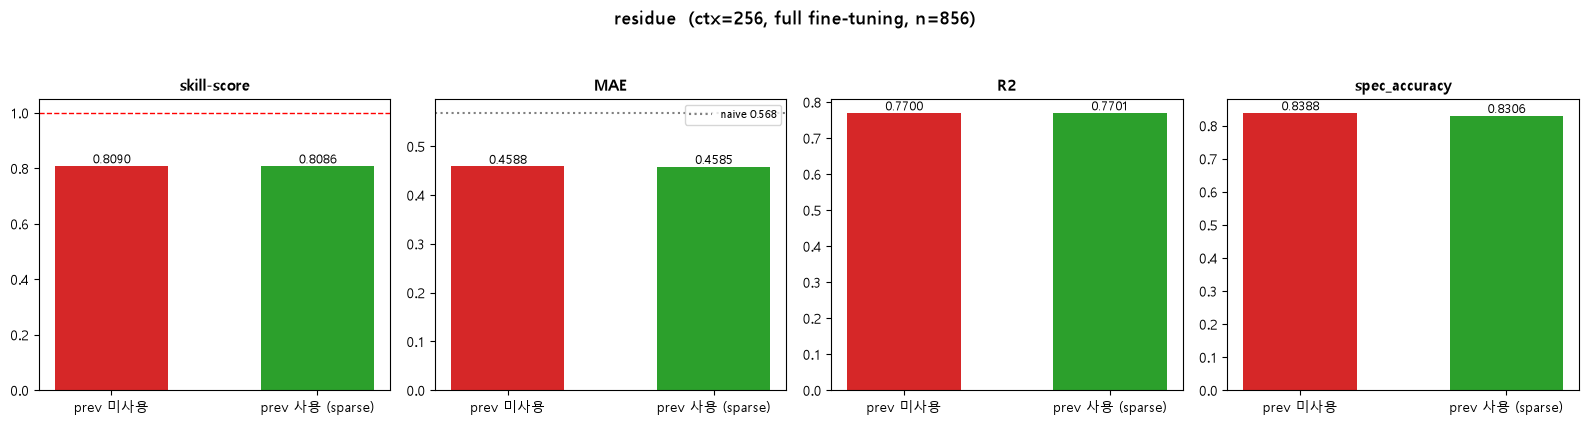

In [5]:
def plot_target(t):
    d = {arm: res[(t, arm)] for arm in ARMS}
    m = {arm: compute_metrics(d[arm], cfg.SPEC_RANGES[t]) for arm in ARMS}
    sk = {arm: normalized_skill_score(d[arm]) for arm in ARMS}
    nmae = float(np.abs(d['prev']['actual'] - d['prev']['naive_pred']).mean())
    panels = [('skill-score', sk, None), ('MAE', {k: m[k]['MAE'] for k in ARMS}, nmae),
              ('R2', {k: m[k]['R2'] for k in ARMS}, None),
              ('spec_accuracy', {k: m[k]['spec_accuracy'] for k in ARMS}, None)]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f'{t}  (ctx={CTX[t]}, full fine-tuning, n={len(d["prev"])})',
                 fontsize=13, fontweight='bold', y=1.05)
    for ax, (name, vals, naive) in zip(axes, panels):
        xs = np.arange(len(ARMS))
        bars = ax.bar(xs, [vals[a] for a in ARMS], color=[COLOR[a] for a in ARMS], width=0.55)
        for bb, a in zip(bars, ARMS):
            ax.text(bb.get_x() + bb.get_width() / 2, bb.get_height(), f'{vals[a]:.4f}',
                    ha='center', va='bottom', fontsize=9)
        if naive is not None:
            ax.axhline(naive, color='grey', ls=':', label=f'naive {naive:.3f}'); ax.legend(fontsize=8)
        if name == 'skill-score':
            ax.axhline(1.0, color='red', ls='--', lw=1)
        ax.set_xticks(xs); ax.set_xticklabels([LABEL[a] for a in ARMS])
        ax.set_title(name, fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()

for t in cfg.TARGET_COLS:
    plot_target(t)


## 5. 결론

In [6]:
for t in cfg.TARGET_COLS:
    a, b = res[(t, 'noprev')], res[(t, 'prev')]
    sa, sb = normalized_skill_score(a), normalized_skill_score(b)
    ma = compute_metrics(a, cfg.SPEC_RANGES[t])['MAE']
    mb = compute_metrics(b, cfg.SPEC_RANGES[t])['MAE']
    win = 'prev 사용' if sb < sa else 'prev 미사용'
    print(f'{t:8s}: noprev skill={sa:.4f} MAE={ma:.4f}  |  prev skill={sb:.4f} MAE={mb:.4f}  -> {win} 우세 '
          f'(Δskill={sb-sa:+.4f})')


blaine  : noprev skill=0.8363 MAE=69.9970  |  prev skill=0.8319 MAE=69.6349  -> prev 사용 우세 (Δskill=-0.0045)
residue : noprev skill=0.8090 MAE=0.4588  |  prev skill=0.8086 MAE=0.4585  -> prev 사용 우세 (Δskill=-0.0005)


<!-- 결론 텍스트는 EXPERIMENT_LOG.md 참조 -->